# 🏷️ DoNext 5G — NB4_DSO4 : Prédiction Type de Handover

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → DSO1 ✅ → DSO2 ✅ → DSO3 ✅ → **NB4_DSO4**

Classes 3GPP : `intra_freq` | `inter_freq` | `inter_RAT_NR` | `inter_operator` | `intra_freq_pci` | `inter_freq_pci` | `ho_non_type`

| # | Modèle | Type |
|---|--------|------|
| M1 | XGBoost | Classique |
| M2 | LightGBM | Classique |
| M3 | Random Forest | Classique |
| M4 | BiLSTM Softmax | Deep Learning |
| M5 | TabNet (pré-entraîné) | Pré-entraîné |

---
## Section 0 — Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27','axes.edgecolor':'#3A3D4D',
    'axes.labelcolor':'#E0E0E0','axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0','grid.color':'#2A2D3A',
    'grid.linestyle':'--','grid.alpha':0.5,'font.family':'monospace','figure.dpi':130})
BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'; RED='#EF5350'; PURPLE='#CE93D8'

HO_TYPE_NAMES=['no_handover','intra_freq','inter_freq','inter_RAT_NR',
               'inter_operator','intra_freq_pci','inter_freq_pci','ho_non_type']

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'  # ← adapter
PT_OUT_DIR    = os.path.join(DATASET_ROOT,'PT_output')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT,'MODEL_output','DSO4')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)
print('✅ Setup OK')

✅ Setup OK


---
## Section 1 — Préparation des données DSO4

In [3]:
df=pd.read_parquet(os.path.join(PT_OUT_DIR,'df_preprocessed.parquet'))
assert 'ho_type_enc' in df.columns and 'handover' in df.columns
df_ho4=df[df['handover']==1].copy()
print(f'Handovers : {len(df_ho4):,}')
ho_dist=df_ho4['ho_type_enc'].value_counts().sort_index()
for enc,cnt in ho_dist.items():
    name=HO_TYPE_NAMES[int(enc)] if int(enc)<len(HO_TYPE_NAMES) else f'type_{enc}'
    print(f'  {name:<20}: {cnt:>8,} ({cnt/len(df_ho4)*100:.1f}%)')

Handovers : 975,465
  intra_freq          :  150,123 (15.4%)
  inter_freq          :   59,376 (6.1%)
  inter_RAT_NR        :    5,383 (0.6%)
  inter_operator      :       25 (0.0%)
  intra_freq_pci      :      358 (0.0%)
  inter_freq_pci      :      566 (0.1%)
  ho_non_type         :  759,634 (77.9%)


In [4]:
with open(os.path.join(PT_OUT_DIR,'config.json')) as f: config=json.load(f)
COLS_X=[c for c in config['cols_X'] if c in df_ho4.columns and c not in ['handover','ho_type_enc']]
X_all=df_ho4[COLS_X].values.astype(np.float32)
y_all=df_ho4['ho_type_enc'].values.astype(int)
unique_classes=np.unique(y_all)
remap={old:new for new,old in enumerate(unique_classes)}
y_all_enc=np.array([remap[y] for y in y_all])
N_CLASSES=len(unique_classes)
CLASS_NAMES=[HO_TYPE_NAMES[int(c)] if int(c)<len(HO_TYPE_NAMES) else f'type_{c}' for c in unique_classes]
n=len(X_all); n_tr=int(n*0.7); n_va=int(n*0.15)
X_train,X_val,X_test=X_all[:n_tr],X_all[n_tr:n_tr+n_va],X_all[n_tr+n_va:]
y_train,y_val,y_test=y_all_enc[:n_tr],y_all_enc[n_tr:n_tr+n_va],y_all_enc[n_tr+n_va:]
cw_arr=compute_class_weight('balanced',classes=np.arange(N_CLASSES),y=y_train)
cw_dict={i:cw_arr[i] for i in range(N_CLASSES)}
print(f'N_CLASSES={N_CLASSES} | Classes={CLASS_NAMES}')

N_CLASSES=7 | Classes=['intra_freq', 'inter_freq', 'inter_RAT_NR', 'inter_operator', 'intra_freq_pci', 'inter_freq_pci', 'ho_non_type']


---
## Section 2 — M1 : XGBoost

In [5]:
print('='*60+'\n  M1 — XGBoost DSO4\n'+'='*60)
sw_train=np.array([cw_dict[y] for y in y_train],dtype=np.float32)
xgb_d4=XGBClassifier(n_estimators=400,max_depth=7,learning_rate=0.08,subsample=0.8,
    colsample_bytree=0.8,objective='multi:softmax',num_class=N_CLASSES,
    eval_metric='mlogloss',early_stopping_rounds=25,tree_method='hist',
    random_state=42,n_jobs=-1,use_label_encoder=False)
xgb_d4.fit(X_train,y_train,sample_weight=sw_train,eval_set=[(X_val,y_val)],verbose=40)
y_pred_xgb=xgb_d4.predict(X_test)
print(classification_report(y_test,y_pred_xgb,target_names=CLASS_NAMES,zero_division=0))
metrics_xgb={'model':'XGBoost','accuracy':round(accuracy_score(y_test,y_pred_xgb),4),
    'f1_macro':round(f1_score(y_test,y_pred_xgb,average='macro',zero_division=0),4),
    'f1_weighted':round(f1_score(y_test,y_pred_xgb,average='weighted',zero_division=0),4)}
with open(os.path.join(MODEL_OUT_DIR,'xgb_dso4.pkl'),'wb') as f: pickle.dump(xgb_d4,f)

  M1 — XGBoost DSO4
[0]	validation_0-mlogloss:1.73818
[40]	validation_0-mlogloss:0.55985
[80]	validation_0-mlogloss:0.46147
[113]	validation_0-mlogloss:0.47949
                precision    recall  f1-score   support

    intra_freq       0.85      0.59      0.69    106710
    inter_freq       0.37      0.59      0.45     33841
  inter_RAT_NR       0.07      0.87      0.13       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.20      0.00        40
inter_freq_pci       0.03      0.04      0.03       107
   ho_non_type       0.78      0.83      0.80      5071

      accuracy                           0.60    146321
     macro avg       0.30      0.44      0.30    146321
  weighted avg       0.73      0.60      0.64    146321



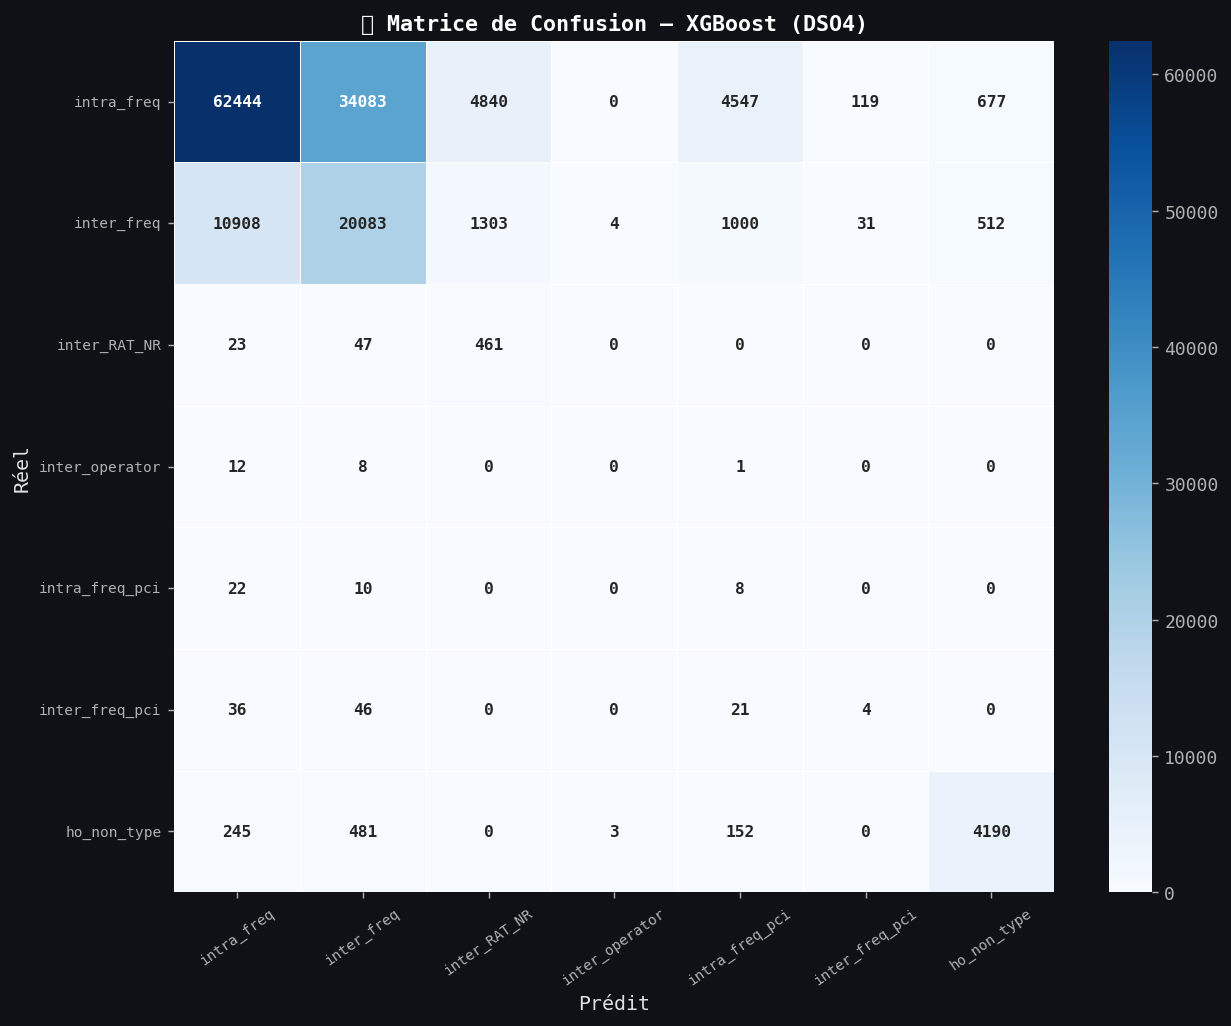

In [6]:
# ── Matrice de Confusion — XGBoost ───────────────────────────────────────────
cm_xgb=confusion_matrix(y_test,y_pred_xgb,labels=list(range(N_CLASSES)))
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_xgb,annot=True,fmt='d',cmap='Blues',
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.4,ax=ax,annot_kws={'size':9,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.tick_params(axis='x',rotation=35,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
ax.set_title('🔢 Matrice de Confusion — XGBoost (DSO4)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_xgb_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 3 — M2 : LightGBM

In [7]:
print('='*60+'\n  M2 — LightGBM DSO4\n'+'='*60)
lgbm_d4=LGBMClassifier(n_estimators=400,max_depth=8,learning_rate=0.08,num_leaves=127,
    subsample=0.8,colsample_bytree=0.8,objective='multiclass',num_class=N_CLASSES,
    metric='multi_logloss',class_weight='balanced',random_state=42,n_jobs=-1,verbose=-1)
lgbm_d4.fit(X_train,y_train,eval_set=[(X_val,y_val)],
    callbacks=[lgb.early_stopping(25,verbose=False),lgb.log_evaluation(40)])
y_pred_lgbm=lgbm_d4.predict(X_test)
print(classification_report(y_test,y_pred_lgbm,target_names=CLASS_NAMES,zero_division=0))
metrics_lgbm={'model':'LightGBM','accuracy':round(accuracy_score(y_test,y_pred_lgbm),4),
    'f1_macro':round(f1_score(y_test,y_pred_lgbm,average='macro',zero_division=0),4),
    'f1_weighted':round(f1_score(y_test,y_pred_lgbm,average='weighted',zero_division=0),4)}
with open(os.path.join(MODEL_OUT_DIR,'lgbm_dso4.pkl'),'wb') as f: pickle.dump(lgbm_d4,f)

  M2 — LightGBM DSO4
[40]	valid_0's multi_logloss: 0.443122
[80]	valid_0's multi_logloss: 0.346127
[120]	valid_0's multi_logloss: 0.351867
                precision    recall  f1-score   support

    intra_freq       0.86      0.68      0.76    106710
    inter_freq       0.39      0.62      0.48     33841
  inter_RAT_NR       0.24      0.87      0.38       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.05      0.01        40
inter_freq_pci       0.02      0.08      0.03       107
   ho_non_type       0.92      0.98      0.95      5071

      accuracy                           0.68    146321
     macro avg       0.35      0.47      0.37    146321
  weighted avg       0.75      0.68      0.70    146321



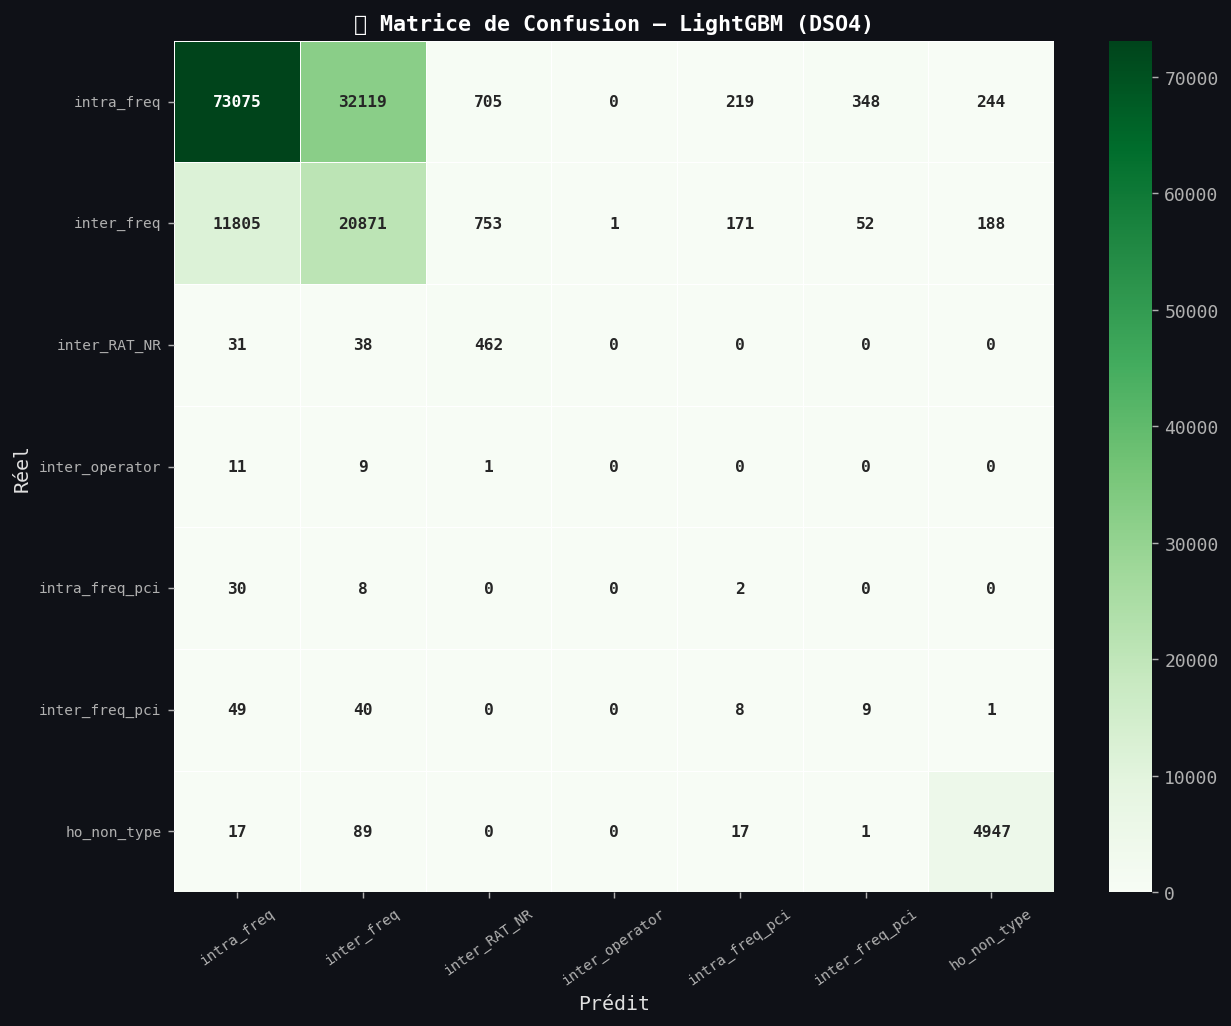

In [8]:
# ── Matrice de Confusion — LightGBM ──────────────────────────────────────────
cm_lgbm=confusion_matrix(y_test,y_pred_lgbm,labels=list(range(N_CLASSES)))
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_lgbm,annot=True,fmt='d',cmap='Greens',
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.4,ax=ax,annot_kws={'size':9,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.tick_params(axis='x',rotation=35,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
ax.set_title('🔢 Matrice de Confusion — LightGBM (DSO4)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 4 — M3 : Random Forest

In [9]:
print('='*60+'\n  M3 — Random Forest DSO4\n'+'='*60)
rf_d4=RandomForestClassifier(n_estimators=250,max_depth=18,min_samples_leaf=5,
    max_features='sqrt',class_weight='balanced_subsample',max_samples=0.4,
    random_state=42,n_jobs=-1,verbose=1)
rf_d4.fit(X_train,y_train)
y_pred_rf=rf_d4.predict(X_test)
print(classification_report(y_test,y_pred_rf,target_names=CLASS_NAMES,zero_division=0))
metrics_rf={'model':'Random Forest','accuracy':round(accuracy_score(y_test,y_pred_rf),4),
    'f1_macro':round(f1_score(y_test,y_pred_rf,average='macro',zero_division=0),4),
    'f1_weighted':round(f1_score(y_test,y_pred_rf,average='weighted',zero_division=0),4)}
with open(os.path.join(MODEL_OUT_DIR,'rf_dso4.pkl'),'wb') as f: pickle.dump(rf_d4,f)

  M3 — Random Forest DSO4


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   14.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 250 out of 250 | elapsed:    0.5s finished


                precision    recall  f1-score   support

    intra_freq       0.83      0.77      0.80    106710
    inter_freq       0.42      0.56      0.48     33841
  inter_RAT_NR       0.33      0.14      0.20       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.11      0.17      0.14        40
inter_freq_pci       0.00      0.00      0.00       107
   ho_non_type       1.00      0.45      0.62      5071

      accuracy                           0.70    146321
     macro avg       0.38      0.30      0.32    146321
  weighted avg       0.74      0.70      0.71    146321



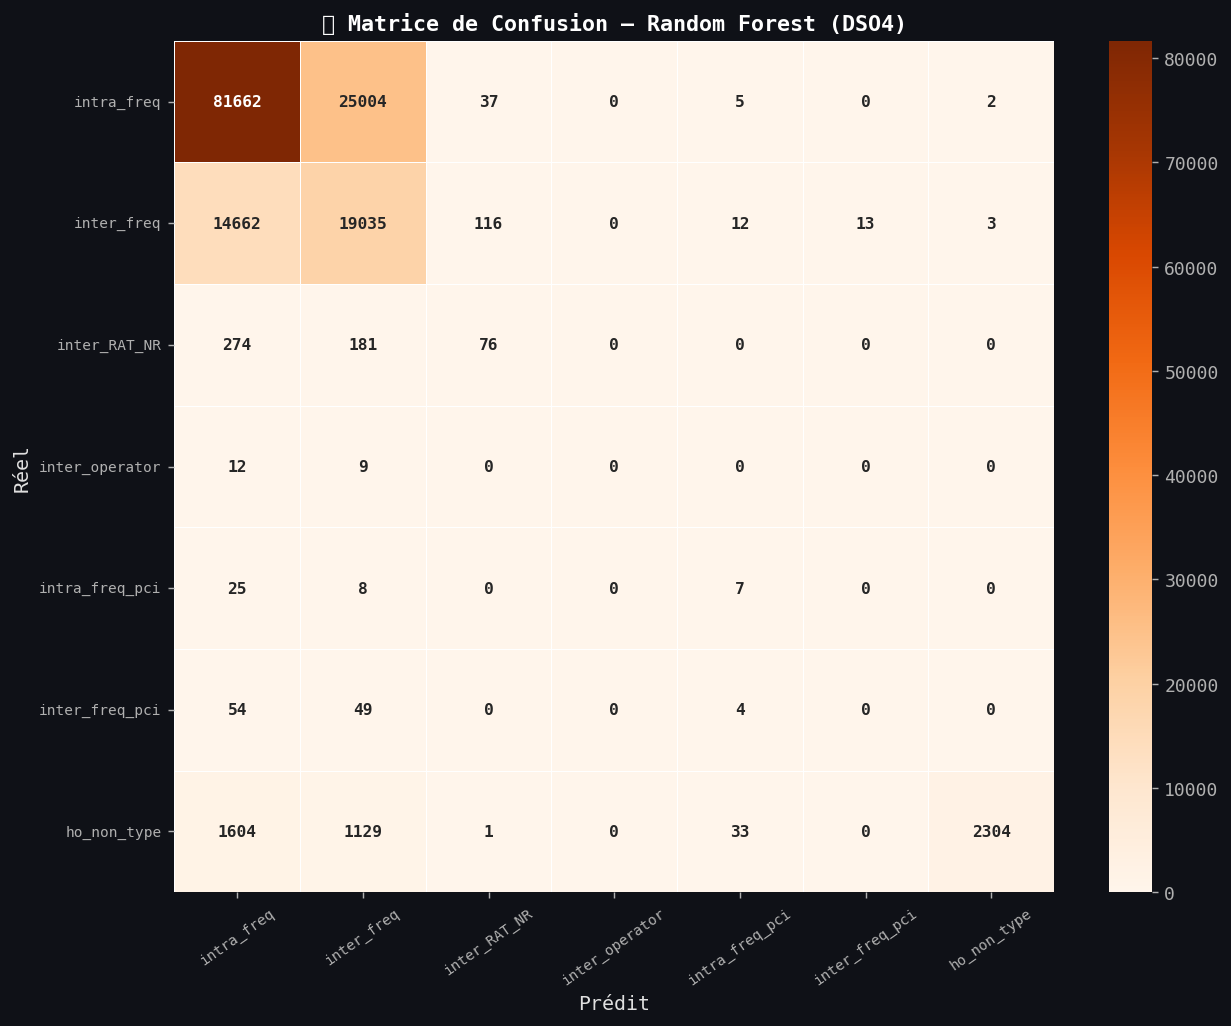

In [10]:
# ── Matrice de Confusion — Random Forest ─────────────────────────────────────
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=list(range(N_CLASSES)))
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Oranges',
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.4,ax=ax,annot_kws={'size':9,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.tick_params(axis='x',rotation=35,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
ax.set_title('🔢 Matrice de Confusion — Random Forest (DSO4)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_rf_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 5 — M4 : BiLSTM Softmax (Deep Learning)

In [11]:
print('='*60+'\n  M4 — BiLSTM DSO4\n'+'='*60)
WINDOW_COLS=[c for c in COLS_X if any(f'_t-{k}' in c for k in range(1,6))]
T=5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx=[list(COLS_X).index(c) for c in WINDOW_COLS]; F=len(w_idx)//T
    X_tr_3d=X_train[:,w_idx].reshape(-1,T,F); X_va_3d=X_val[:,w_idx].reshape(-1,T,F); X_te_3d=X_test[:,w_idx].reshape(-1,T,F)
else:
    F=X_train.shape[1]; T=1
    X_tr_3d=X_train.reshape(-1,1,F); X_va_3d=X_val.reshape(-1,1,F); X_te_3d=X_test.reshape(-1,1,F)
y_tr_cat=to_categorical(y_train,N_CLASSES); y_va_cat=to_categorical(y_val,N_CLASSES)
tf.random.set_seed(42)
inp=Input(shape=(T,F))
x=Bidirectional(LSTM(128,return_sequences=True,dropout=0.2))(inp)
x=BatchNormalization()(x); x=Bidirectional(LSTM(64,return_sequences=False,dropout=0.2))(x)
x=BatchNormalization()(x); x=Dense(128,activation='relu')(x)
x=Dropout(0.35)(x); x=Dense(64,activation='relu')(x)
out=Dense(N_CLASSES,activation='softmax')(x)
lstm_d4=Model(inputs=inp,outputs=out,name='LSTM_DSO4')
lstm_d4.compile(optimizer=Adam(1e-3),loss='categorical_crossentropy',metrics=['accuracy'])
history_d4=lstm_d4.fit(X_tr_3d,y_tr_cat,validation_data=(X_va_3d,y_va_cat),
    class_weight=cw_dict,epochs=30,batch_size=1024,verbose=1,
    callbacks=[EarlyStopping(monitor='val_accuracy',patience=5,restore_best_weights=True,mode='max'),
               ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6),
               ModelCheckpoint(os.path.join(MODEL_OUT_DIR,'lstm_dso4_best.h5'),monitor='val_accuracy',save_best_only=True,mode='max')])
y_proba_lstm=lstm_d4.predict(X_te_3d,batch_size=2048,verbose=0); y_pred_lstm=y_proba_lstm.argmax(axis=1)
print(classification_report(y_test,y_pred_lstm,target_names=CLASS_NAMES,zero_division=0))
metrics_lstm={'model':'BiLSTM','accuracy':round(accuracy_score(y_test,y_pred_lstm),4),
    'f1_macro':round(f1_score(y_test,y_pred_lstm,average='macro',zero_division=0),4),
    'f1_weighted':round(f1_score(y_test,y_pred_lstm,average='weighted',zero_division=0),4)}
lstm_d4.save(os.path.join(MODEL_OUT_DIR,'lstm_dso4.h5'))

  M4 — BiLSTM DSO4
Epoch 1/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1569 - loss: 2.3096 

667/667 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.1370 - loss: 2.5019 - val_accuracy: 0.0011 - val_loss: 1.8578 - learning_rate: 0.0010
Epoch 2/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.1822 - loss: 2.4888 - val_accuracy: 0.0011 - val_loss: 1.8405 - learning_rate: 0.0010
Epoch 3/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.1179 - loss: 2.2173 - val_accuracy: 0.0011 - val_loss: 1.8578 - learning_rate: 0.0010
Epoch 4/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0632 - loss: 1.9650 

667/667 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.0937 - loss: 2.1129 - val_accuracy: 0.0289 - val_loss: 1.8360 - learning_rate: 0.0010
Epoch 5/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.1400 - loss: 2.3513 - val_accuracy: 0.0011 - val_loss: 1.7566 - learning_rate: 0.0010
Epoch 6/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.1020 - loss: 2.5033 - val_accuracy: 0.0289 - val_loss: 1.8316 - learning_rate: 0.0010
Epoch 7/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.1156 - loss: 2.5853 - val_accuracy: 0.0289 - val_loss: 1.8663 - learning_rate: 0.0010
Epoch 8/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.1020 - loss: 2.4797 - val_accuracy: 0.0011 - val_loss: 1.8698 - learning_rate: 0.0010
Epoch 9/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.0736 - loss: 2.6784 - val_accuracy: 0.0289 - val_loss: 1.9349 - learning_rate: 5.0000e-04


                precision    recall  f1-score   support

    intra_freq       0.00      0.00      0.00    106710
    inter_freq       0.00      0.00      0.00     33841
  inter_RAT_NR       0.00      1.00      0.01       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.00      0.00        40
inter_freq_pci       0.00      0.00      0.00       107
   ho_non_type       0.00      0.00      0.00      5071

      accuracy                           0.00    146321
     macro avg       0.00      0.14      0.00    146321
  weighted avg       0.00      0.00      0.00    146321



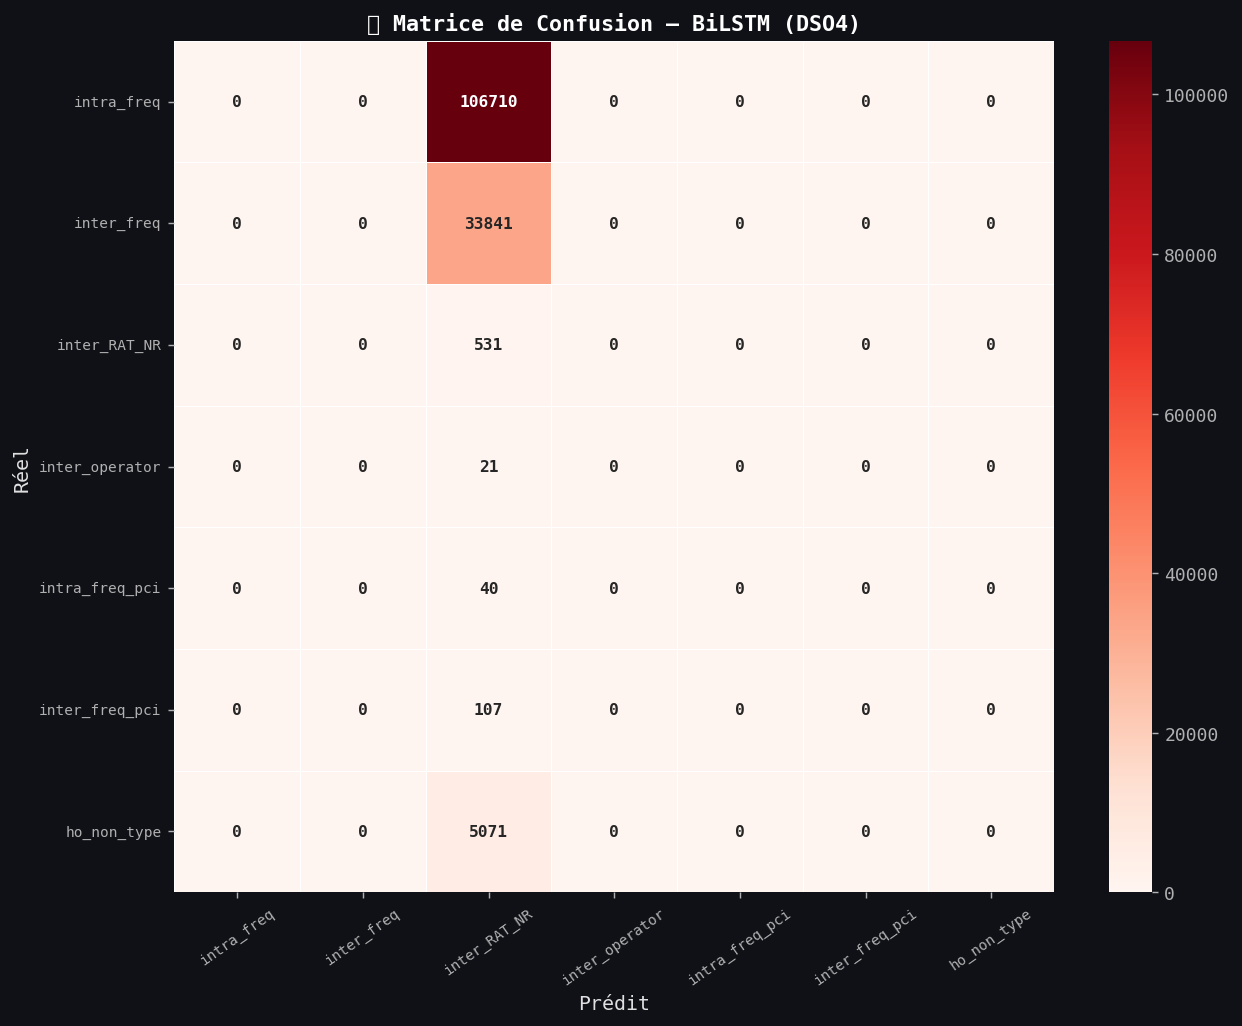

In [12]:
# ── Matrice de Confusion — BiLSTM ────────────────────────────────────────────
cm_lstm=confusion_matrix(y_test,y_pred_lstm,labels=list(range(N_CLASSES)))
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_lstm,annot=True,fmt='d',cmap='Reds',
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.4,ax=ax,annot_kws={'size':9,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.tick_params(axis='x',rotation=35,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
ax.set_title('🔢 Matrice de Confusion — BiLSTM (DSO4)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lstm_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 6 — M5 : TabNet (Pré-entraîné)

In [15]:
print('='*60+'\n  M5 — TabNet DSO4\n'+'='*60)

# ── 1. float32 + sampling ────────────────────────────────────
N_TN = min(100_000, len(X_train))
idx_tn = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_tn].astype(np.float32)   # ✅ float32
X_va_tn    = X_val.astype(np.float32)
X_te_tn    = X_test.astype(np.float32)
y_train_tn = y_train[idx_tn]
print(f'Sample train : {len(X_tr_tn)}')

# ── 2. Pretraining ───────────────────────────────────────────
pt_d4 = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,         # ✅ n_d/n_a réduit, n_steps=3
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=5, seed=42
)
pt_d4.fit(
    X_train=X_tr_tn,                               # ✅ pas de concat
    eval_set=[X_va_tn],
    max_epochs=30, patience=5,                     # ✅ epochs réduits
    batch_size=2048, virtual_batch_size=256,
    pretraining_ratio=0.5
)

# ── 3. Modèle supervisé ─────────────────────────────────────
tabnet_d4 = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# ✅ Mini-fit pour initialiser le réseau
tabnet_d4.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512, virtual_batch_size=512
)

# ✅ Transfert des poids encodeur
tabnet_d4.load_weights_from_unsupervised(pt_d4)

# ── 4. Entraînement réel ─────────────────────────────────────
tabnet_d4.verbose = 10
tabnet_d4.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['accuracy'],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    weights=1
)

# ── 5. Évaluation ────────────────────────────────────────────
y_pred_tn = tabnet_d4.predict(X_te_tn)
print(classification_report(y_test, y_pred_tn, target_names=CLASS_NAMES, zero_division=0))
metrics_tn = {
    'model':       'TabNet',
    'accuracy':    round(accuracy_score(y_test, y_pred_tn), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_tn, average='macro',    zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_tn, average='weighted', zero_division=0), 4)
}
tabnet_d4.save_model(os.path.join(MODEL_OUT_DIR, 'tabnet_dso4'))

  M5 — TabNet DSO4
Sample train : 100000
epoch 0  | loss: 69255.052| val_0_unsup_loss_numpy: 412333.34375|  0:00:30s
epoch 5  | loss: 13002.98759| val_0_unsup_loss_numpy: 392785.25|  0:02:51s
epoch 10 | loss: 13005.05601| val_0_unsup_loss_numpy: 396485.75|  0:05:00s

Early stopping occurred at epoch 11 with best_epoch = 6 and best_val_0_unsup_loss_numpy = 392625.59375
epoch 0  | loss: 1.50798 | val_0_accuracy: 0.02889 |  0:00:22s

Early stopping occurred at epoch 8 with best_epoch = 3 and best_val_0_accuracy = 0.23808
                precision    recall  f1-score   support

    intra_freq       0.72      0.70      0.71    106710
    inter_freq       0.30      0.03      0.06     33841
  inter_RAT_NR       0.00      0.00      0.00       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.05      0.00        40
inter_freq_pci       0.00      0.00      0.00       107
   ho_non_type       0.00      0.00      0.00      5071

      accuracy            

'C:\\Users\\THINKPAD\\Desktop\\DATASET\\MODEL_output\\DSO4\\tabnet_dso4.zip'

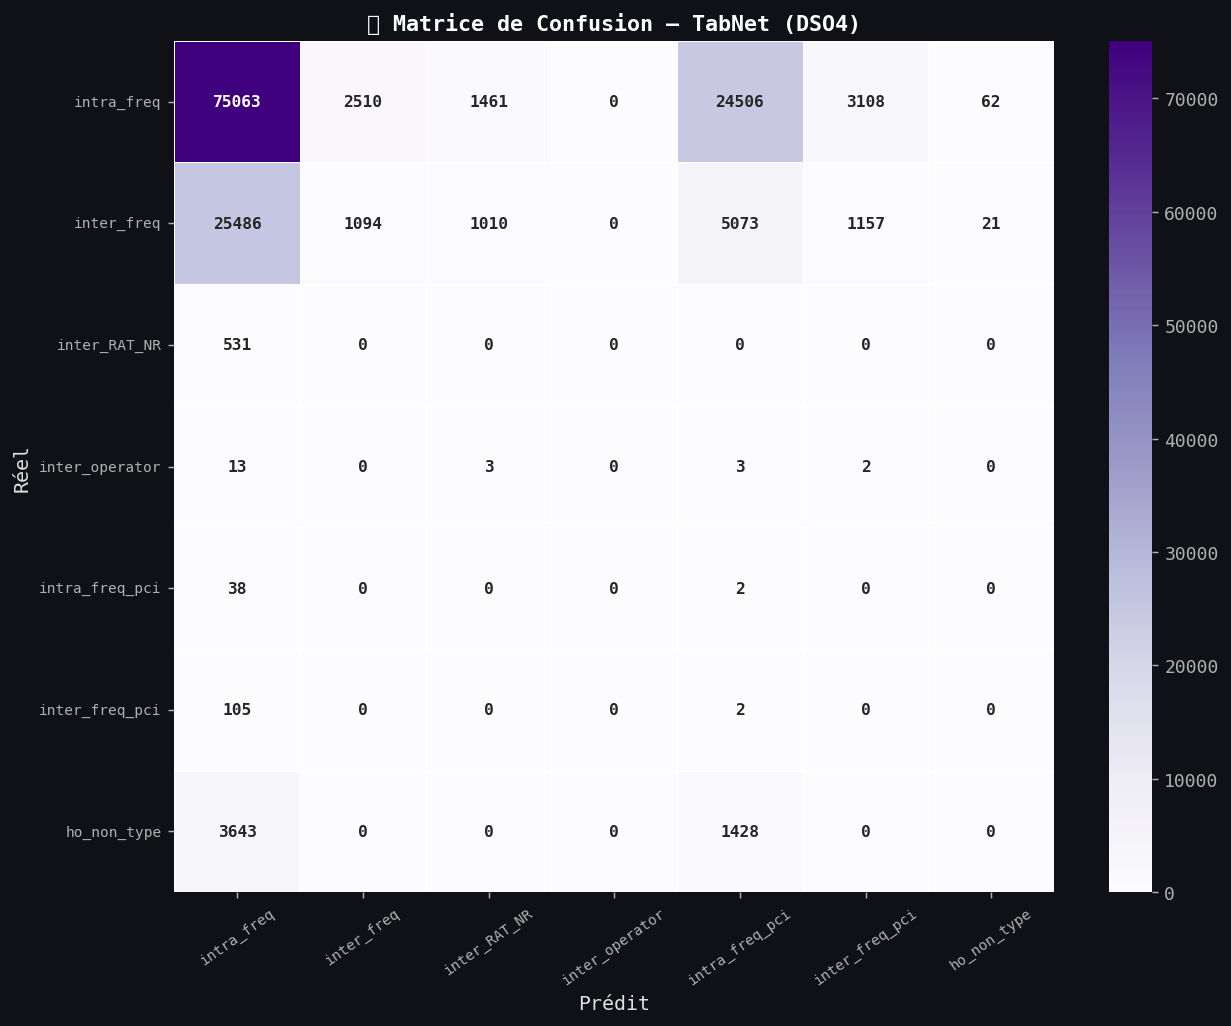

In [16]:
# ── Matrice de Confusion — TabNet ────────────────────────────────────────────
cm_tn=confusion_matrix(y_test,y_pred_tn,labels=list(range(N_CLASSES)))
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_tn,annot=True,fmt='d',cmap='Purples',
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.4,ax=ax,annot_kws={'size':9,'weight':'bold'})
ax.set_xlabel('Prédit',fontsize=11); ax.set_ylabel('Réel',fontsize=11)
ax.tick_params(axis='x',rotation=35,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
ax.set_title('🔢 Matrice de Confusion — TabNet (DSO4)',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 7 — Grille comparative & Dashboard Final

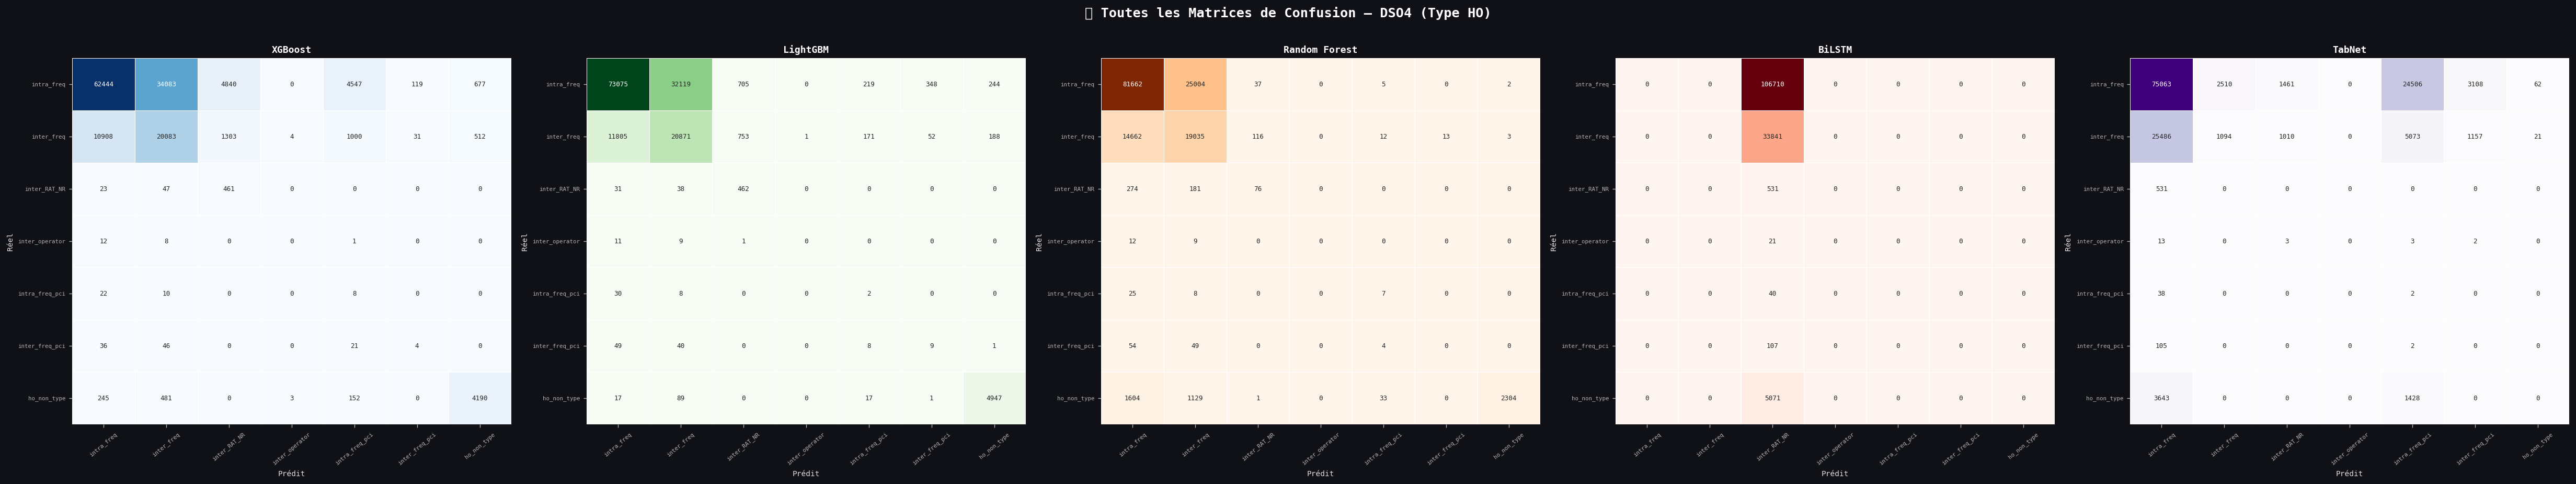

               accuracy  f1_macro  f1_weighted
model                                         
XGBoost          0.5959    0.3015       0.6380
LightGBM         0.6791    0.3727       0.7011
Random Forest    0.7045    0.3200       0.7145
BiLSTM           0.0036    0.0010       0.0000
TabNet           0.5205    0.1097       0.5310

🏆 Meilleur (F1-macro) : LightGBM → 0.3727


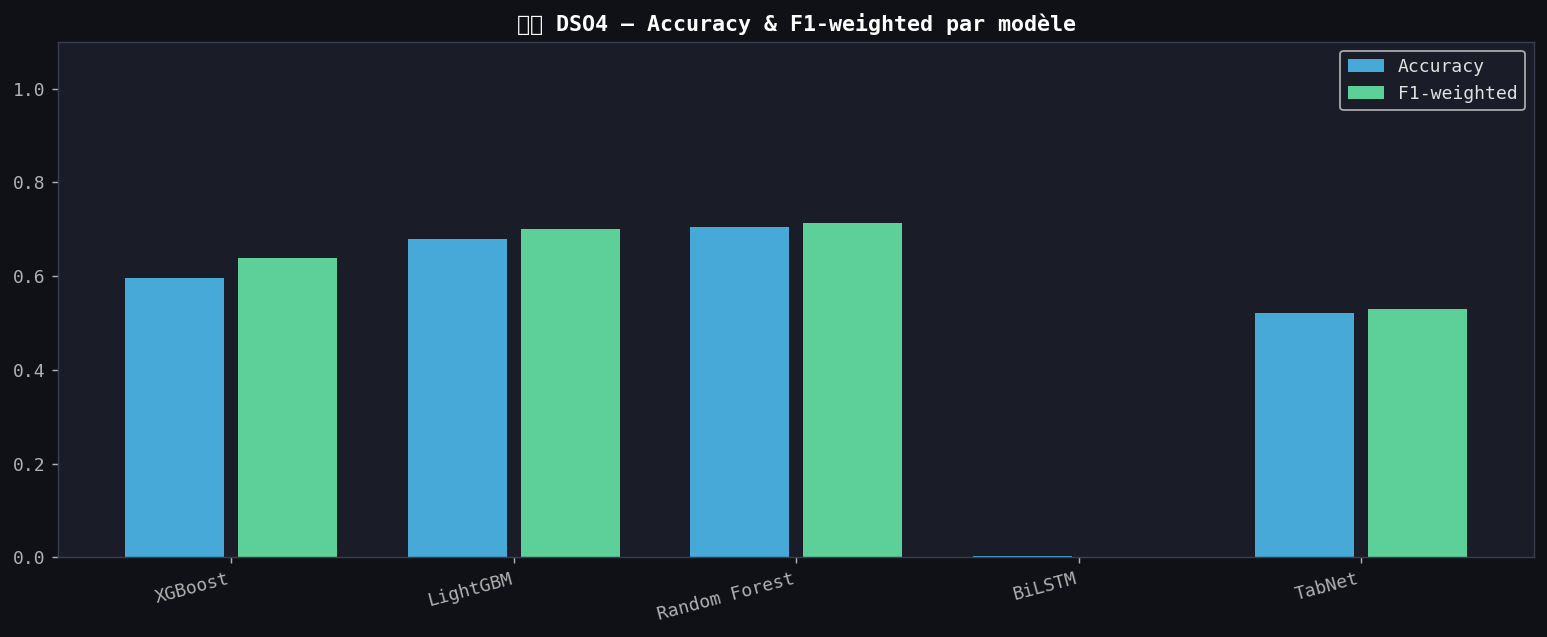


🎉 Pipeline complet : NB1→NB2→NB3→DSO1→DSO2→DSO3→DSO4 ✅


In [17]:
# ── Grille 1×5 — toutes les matrices côte à côte ─────────────────────────────
fig,axes=plt.subplots(1,5,figsize=(38,7))
models_cm=[('XGBoost',cm_xgb,y_pred_xgb,'Blues'),('LightGBM',cm_lgbm,y_pred_lgbm,'Greens'),
           ('Random Forest',cm_rf,y_pred_rf,'Oranges'),('BiLSTM',cm_lstm,y_pred_lstm,'Reds'),
           ('TabNet',cm_tn,y_pred_tn,'Purples')]
for ax,(name,cm,_,cmap) in zip(axes,models_cm):
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
        linewidths=0.3,ax=ax,annot_kws={'size':7},cbar=False)
    ax.set_title(name,fontsize=10,fontweight='bold')
    ax.tick_params(axis='x',rotation=40,labelsize=6); ax.tick_params(axis='y',labelsize=6)
    ax.set_xlabel('Prédit',fontsize=8); ax.set_ylabel('Réel',fontsize=8)
plt.suptitle('🔢 Toutes les Matrices de Confusion — DSO4 (Type HO)',fontsize=14,fontweight='bold',color='white',y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_all_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

all_metrics=[metrics_xgb,metrics_lgbm,metrics_rf,metrics_lstm,metrics_tn]
df_results=pd.DataFrame(all_metrics).set_index('model')
print(df_results.to_string())
best=df_results['f1_macro'].idxmax()
print(f'\n🏆 Meilleur (F1-macro) : {best} → {df_results.loc[best,"f1_macro"]:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'results_dso4.json'),'w') as f: json.dump(all_metrics,f,indent=2)

x=np.arange(5); models_list=['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(x-0.2,df_results['accuracy'],0.35,label='Accuracy',color=BLUE,alpha=0.85)
ax.bar(x+0.2,df_results['f1_weighted'],0.35,label='F1-weighted',color=GREEN,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models_list,rotation=15,ha='right')
ax.set_title('🏷️ DSO4 — Accuracy & F1-weighted par modèle',fontweight='bold')
ax.legend(); ax.set_ylim(0,1.1)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'dashboard_dso4.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()
print('\n🎉 Pipeline complet : NB1→NB2→NB3→DSO1→DSO2→DSO3→DSO4 ✅')